# Wastewater surveillance, CDC NWSS (Lane A: you prompt, the agent builds)

**SISMID 2026 - Day 2, 9:00.** Drive **Codex / Claude Code / Antigravity CLI**. Each prompt
produces roughly the matching Lane B cell. Not set up? Use Lane B.


## Step 0: point the agent at the task

> *From CDC's National Wastewater Surveillance System open data on data.cdc.gov (the*
> *'Wastewater Data for Influenza A' dataset, Socrata id `ymmh-divb`), write*
> *`nwss_fetch(state)` that returns a tidy DataFrame for one state, and a `load_cache()`*
> *reading `data/cdc_nwss_influenza_a_ga_cached.csv`. Add `get_ga_flu_wastewater()` that*
> *pulls Georgia, parses the collection date, coerces `pcr_target_avg_conc` to numeric,*
> *and falls back to the cache.*


In [1]:
import urllib.request, urllib.parse, json, os
import pandas as pd

# CDC NWSS 'Wastewater Data for Influenza A' (Socrata dataset ymmh-divb)
NWSS_ID = 'ymmh-divb'
COLS = ['sample_collect_date','site','counties_served','population_served',
        'pcr_target_avg_conc','pcr_target_flowpop_lin','pcr_target_detect']
CACHE_PATHS = ['../data/cdc_nwss_influenza_a_ga_cached.csv',
               'data/cdc_nwss_influenza_a_ga_cached.csv',
               './cdc_nwss_influenza_a_ga_cached.csv']

def nwss_fetch(state='ga'):
    """Influenza A wastewater samples for one state from CDC NWSS. DataFrame or None."""
    params = {'state_territory': state, '$select': ','.join(COLS),
              '$order': 'sample_collect_date', '$limit': '50000'}
    url = f'https://data.cdc.gov/resource/{NWSS_ID}.json?' + urllib.parse.urlencode(params)
    try:
        rows = json.loads(urllib.request.urlopen(url, timeout=45).read())
        return pd.DataFrame(rows)
    except Exception as e:
        print(f'CDC NWSS live pull failed ({type(e).__name__}): {e}')
        return None

def load_cache():
    for p in CACHE_PATHS:
        if os.path.exists(p):
            print(f'Using cached snapshot: {p}')
            return pd.read_csv(p)
    raise FileNotFoundError('NWSS cache not found; check the data/ folder.')

def get_ga_flu_wastewater():
    df = nwss_fetch('ga')
    if df is None or df.empty:
        df = load_cache()
    # tidy: parse date + numeric concentration
    df['date'] = pd.to_datetime(df['sample_collect_date'])
    df['conc'] = pd.to_numeric(df['pcr_target_avg_conc'], errors='coerce')
    return df


## Step 1: pull Georgia flu-A wastewater

> *Use get_ga_flu_wastewater(); print the row count, date range, and number of distinct*
> *sites, and show a few rows with the counties and population served.*


In [2]:
ww = get_ga_flu_wastewater()
print('rows:', len(ww), '| range:', ww['date'].min().date(), 'to', ww['date'].max().date())
print('distinct sites:', ww['site'].nunique())
print(ww[['date','site','counties_served','population_served','conc']].head())


rows: 7093 | range: 2022-06-26 to 2026-07-13
distinct sites: 27
        date site counties_served population_served        conc
0 2022-06-26  337          Fulton            189593     0.00000
1 2022-06-26  336          Fulton             84486     0.00000
2 2022-06-26  338          Fulton            190000     0.00000
3 2022-06-27  326          Fulton             12818  1783.59406
4 2022-06-28  336          Fulton             84486  4213.35639


## Step 2: aggregate to a weekly state signal

> *A single site is noisy. Aggregate to a weekly mean concentration across all Georgia*
> *sites and plot it.*

**Your check:** does the winter flu season show up?


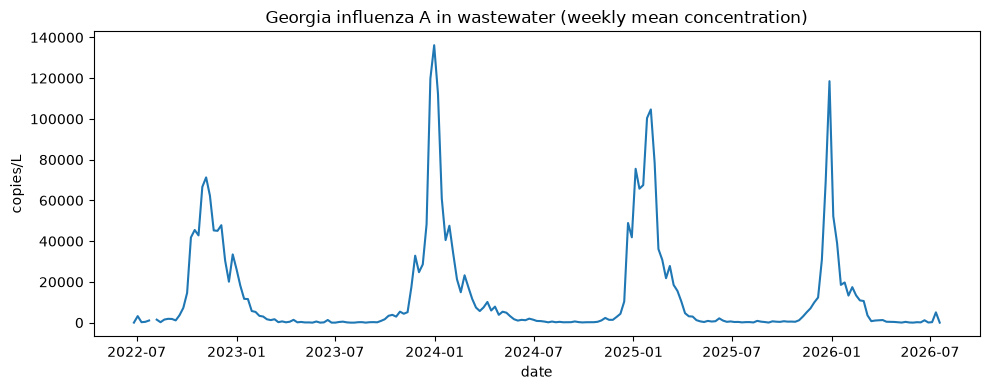

In [3]:
import matplotlib.pyplot as plt

wk = (ww.dropna(subset=['conc'])
        .set_index('date').groupby(pd.Grouper(freq='W'))['conc'].mean().reset_index())
plt.figure(figsize=(10,4))
plt.plot(wk['date'], wk['conc'])
plt.title('Georgia influenza A in wastewater (weekly mean concentration)')
plt.ylabel('copies/L'); plt.xlabel('date'); plt.tight_layout(); plt.show()


## Step 3: single site vs aggregate

> *Overlay the single largest-population site against the state weekly mean, so I can see*
> *why aggregation matters.*


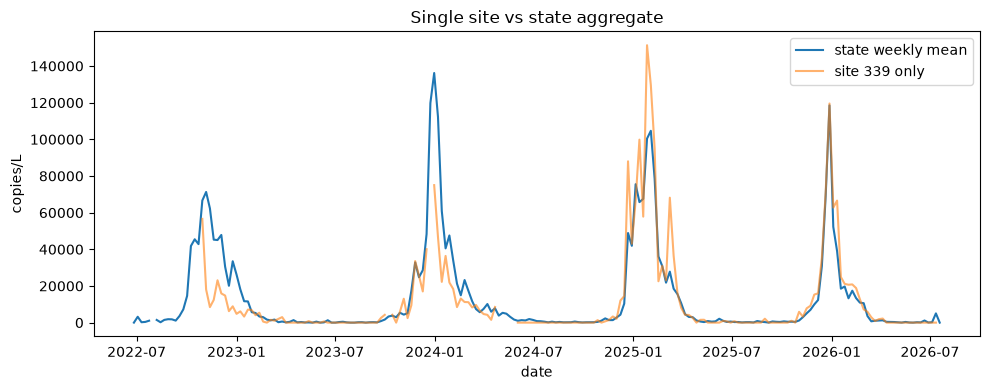

In [4]:
ww['pop'] = pd.to_numeric(ww['population_served'], errors='coerce')
big = ww.sort_values('pop', ascending=False)['site'].iloc[0]
site = (ww[ww['site']==big].dropna(subset=['conc'])
          .set_index('date').groupby(pd.Grouper(freq='W'))['conc'].mean().reset_index())
plt.figure(figsize=(10,4))
plt.plot(wk['date'], wk['conc'], label='state weekly mean')
plt.plot(site['date'], site['conc'], alpha=0.6, label=f'site {big} only')
plt.legend(); plt.title('Single site vs state aggregate'); plt.ylabel('copies/L')
plt.xlabel('date'); plt.tight_layout(); plt.show()


## Step 4: sanity-check and save

> *Report how many sites reported per week recently and the latest sample date (to show*
> *the reporting lag), then save the weekly series to `ga_flu_wastewater_weekly.csv`.*


In [5]:
cov = ww.dropna(subset=['conc']).set_index('date').groupby(pd.Grouper(freq='W'))['site'].nunique()
print('reporting sites per week (last 6):'); print(cov.tail(6))
print('\nlatest sample date:', ww['date'].max().date(), '(expect a lag vs today)')
wk.to_csv('ga_flu_wastewater_weekly.csv', index=False)
print('saved ga_flu_wastewater_weekly.csv', wk.shape)


reporting sites per week (last 6):
date
2026-06-14    21
2026-06-21    19
2026-06-28    18
2026-07-05    15
2026-07-12     8
2026-07-19     1
Freq: W-SUN, Name: site, dtype: int64

latest sample date: 2026-07-13 (expect a lag vs today)
saved ga_flu_wastewater_weekly.csv (213, 2)


## Reflection

- You described the outcome; the agent handled the messy CDC schema.
- Wastewater is biology, not behavior - a stream that fails differently from search.
- On your own: overlay against ILI and judge the lead time.
